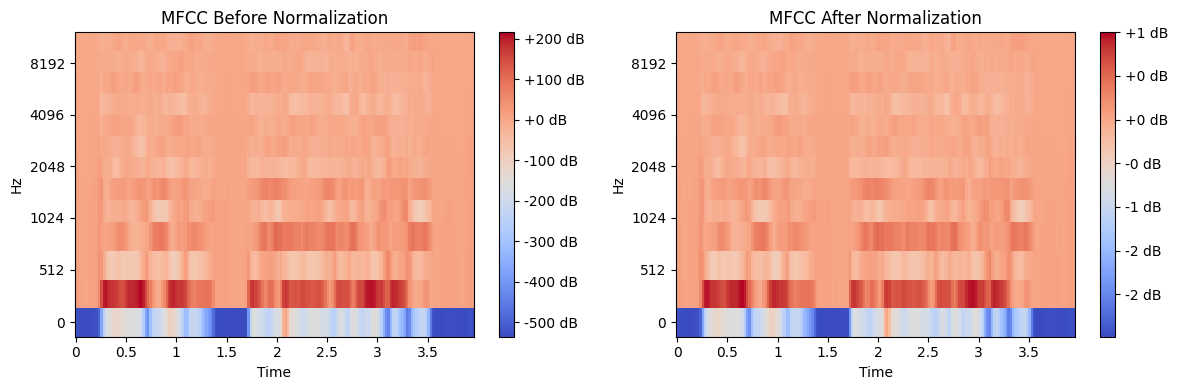

In [1]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# Function to convert audio to MFCC
def audio_to_mfcc(audio_file, sr=22050, n_mfcc=13):
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

# Function to resize spectrogram (if needed)
def resize_spectrogram(spectrogram, target_size=(128, 128)):
    return cv2.resize(spectrogram, target_size)

# Visualization of MFCC before and after normalization
def visualize_normalization(audio_file):
    # Step 1: Load and calculate the MFCC
    mfcc = audio_to_mfcc(audio_file)
    
    # Step 2: Plot the MFCC before normalization
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    librosa.display.specshow(mfcc, sr=22050, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('MFCC Before Normalization')
    
    # Step 3: Normalize the MFCC
    max_value = np.max(mfcc)
    if max_value > 0:
        normalized_mfcc = mfcc / max_value
    else:
        normalized_mfcc = mfcc  # In case the max value is 0

    # Step 4: Plot the MFCC after normalization
    plt.subplot(1, 2, 2)
    librosa.display.specshow(normalized_mfcc, sr=22050, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('MFCC After Normalization')
    
    plt.tight_layout()
    plt.show()

# Example audio file (replace this path with the actual path to a .flac file)
audio_file = r"D:\audio_files\undersampled_audio\DF_E_2000053.flac"

# Visualize normalization process
visualize_normalization(audio_file)


In [2]:
# Path to the metadata file
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'

# Dictionary to hold file identifiers and labels
labels = {}

# Open and read the metadata file
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]  # Example: DF_E_2000011
        label = parts[5]            # Example: "spoof"
        labels[file_identifier] = label

import glob
import os

# Directory containing the undersampled audio files
undersampled_audio_dir = r'D:\audio_files\undersampled_audio'

# Find all .flac files in the undersampled directory
audio_files = glob.glob(os.path.join(undersampled_audio_dir, '*.flac'))

# Create a list to store only those files that have corresponding labels in the metadata
valid_audio_files = []
valid_labels = []

# Loop through the audio files and match with metadata labels
for audio_file in audio_files:
    file_name = os.path.basename(audio_file)
    file_identifier = file_name.split('.')[0]  # Extract the file identifier (before the extension)

    # Check if the file identifier exists in the metadata labels
    if file_identifier in labels:
        valid_audio_files.append(audio_file)  # Keep this audio file
        valid_labels.append(labels[file_identifier])  # Store the corresponding label (spoof/bonafide)

# Print the number of matching files
print(f"Found {len(valid_audio_files)} audio files with corresponding labels.")

import librosa
import numpy as np
import cv2

def audio_to_mfcc(audio_file, sr=22050, n_mfcc=13):
    """Convert audio to MFCC."""
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

def resize_spectrogram(spectrogram, target_size=(128, 128)):
    """Resize the MFCC to a fixed size."""
    return cv2.resize(spectrogram, target_size)

def preprocess_audio_files(audio_files, labels, target_size=(128, 128)):
    """Convert audio files to MFCCs, resize, and normalize them."""
    mfcc_data = []
    label_data = []

    for audio_file, label in zip(audio_files, labels):
        mfcc = audio_to_mfcc(audio_file)
        resized_mfcc = resize_spectrogram(mfcc, target_size)
        
        # Safe normalization: Check if the max value is 0
        max_value = np.max(resized_mfcc)
        if max_value > 0:
            normalized_mfcc = resized_mfcc / max_value
        else:
            normalized_mfcc = resized_mfcc  # Leave it as is if the max is 0

        mfcc_data.append(normalized_mfcc)
        label_data.append(1 if label == 'spoof' else 0)  # Binary label (1: spoof, 0: bonafide)

    return np.array(mfcc_data), np.array(label_data)

# Preprocess the valid audio files and labels
X, y = preprocess_audio_files(valid_audio_files, valid_labels, target_size=(128, 128))

# Add a channel dimension for CNN
X = np.expand_dims(X, axis=-1)

# Split the data into training and validation sets
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

import tensorflow as tf
from tensorflow.keras import layers, models

# Define the CNN architecture
def build_cnn(input_shape):
    model = models.Sequential()
    
    # 1st Convolutional Layer
    model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 2nd Convolutional Layer
    model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 3rd Convolutional Layer
    model.add(layers.Conv2D(128, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten the output and add fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))

    # Output layer (binary classification)
    model.add(layers.Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Define the input shape for the CNN
input_shape = (128, 128, 1)

# Build the model
model = build_cnn(input_shape)

# Print the model summary
model.summary()

# Define early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping])

# Plot accuracy and loss curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()


Found 45234 audio files with corresponding labels.


KeyboardInterrupt: 

Found 4522 audio files with corresponding labels.
Training set distribution: [1582 1582]
Test set distribution: [679 678]


d:\download\fyp\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 124s 77ms/step - accuracy: 0.6884 - loss: 0.6102 - val_accuracy: 0.7605 - val_loss: 0.5401
Epoch 2/5
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 105s 67ms/step - accuracy: 0.7973 - loss: 0.4898 - val_accuracy: 0.7605 - val_loss: 0.5292
Epoch 3/5
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 110s 69ms/step - accuracy: 0.7864 - loss: 0.4878 - val_accuracy: 0.7642 - val_loss: 0.4945
Epoch 4/5
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 120s 76ms/step - accuracy: 0.7968 - loss: 0.4514 - val_accuracy: 0.7642 - val_loss: 0.4909
Epoch 5/5
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 103s 65ms/step - accuracy: 0.8144 - loss: 0.4215 - val_accuracy: 0.7524 - val_loss: 0.5161


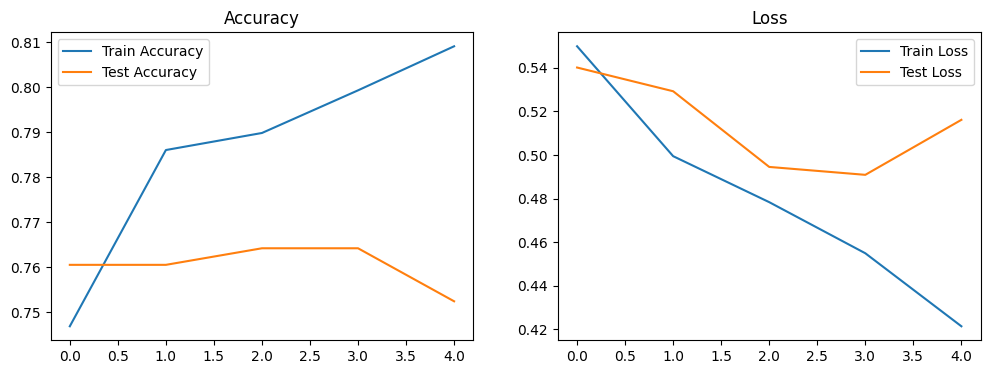

In [3]:
import glob
import os
import librosa
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
import tensorflow as tf
from tensorflow.keras import layers, models

# Path to the metadata file
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'

# Dictionary to hold file identifiers and labels
labels = {}

# Open and read the metadata file
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]  # Example: DF_E_2000011
        label = parts[5]            # Example: "spoof"
        labels[file_identifier] = label

# Directory containing the undersampled audio files
undersampled_audio_dir = r'D:\audio_files\undersampled_audio_10_percent'

# Find all .flac files in the undersampled directory
audio_files = glob.glob(os.path.join(undersampled_audio_dir, '*.flac'))

# Create a list to store only those files that have corresponding labels in the metadata
valid_audio_files = []
valid_labels = []

# Loop through the audio files and match with metadata labels
for audio_file in audio_files:
    file_name = os.path.basename(audio_file)
    file_identifier = file_name.split('.')[0]  # Extract the file identifier (before the extension)

    # Check if the file identifier exists in the metadata labels
    if file_identifier in labels:
        valid_audio_files.append(audio_file)  # Keep this audio file
        valid_labels.append(labels[file_identifier])  # Store the corresponding label (spoof/bonafide)

# Print the number of matching files
print(f"Found {len(valid_audio_files)} audio files with corresponding labels.")

# Audio to MFCC conversion function
def audio_to_mfcc(audio_file, sr=22050, n_mfcc=13):
    """Convert audio to MFCC."""
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

# Resize the MFCC to a fixed size function
def resize_spectrogram(spectrogram, target_size=(128, 128)):
    """Resize the MFCC to a fixed size."""
    return cv2.resize(spectrogram, target_size)

# Preprocessing the audio files
def preprocess_audio_files(audio_files, labels, target_size=(128, 128)):
    """Convert audio files to MFCCs, resize, and normalize them."""
    mfcc_data = []
    label_data = []

    for audio_file, label in zip(audio_files, labels):
        mfcc = audio_to_mfcc(audio_file)
        resized_mfcc = resize_spectrogram(mfcc, target_size)
        
        # Safe normalization: Check if the max value is 0
        max_value = np.max(resized_mfcc)
        if max_value > 0:
            normalized_mfcc = resized_mfcc / max_value
        else:
            normalized_mfcc = resized_mfcc  # Leave it as is if the max is 0

        mfcc_data.append(normalized_mfcc)
        label_data.append(1 if label == 'spoof' else 0)  # Binary label (1: spoof, 0: bonafide)

    return np.array(mfcc_data), np.array(label_data)

# Preprocess the valid audio files and labels
X, y = preprocess_audio_files(valid_audio_files, valid_labels, target_size=(128, 128))

# Add a channel dimension for CNN
X = np.expand_dims(X, axis=-1)

# Stratified 70:30 train-test split
def stratified_split_70_30(X, y, test_size=0.3, random_state=42):
    """Split dataset into stratified 70/30 sets."""
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    
    for train_idx, test_idx in strat_split.split(X, y):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
    
    # Ensure that the training set has balanced classes
    class_counts = np.bincount(y_train)
    min_class_count = min(class_counts)
    spoof_indices = np.where(y_train == 1)[0][:min_class_count]
    bonafide_indices = np.where(y_train == 0)[0][:min_class_count]
    balanced_train_indices = np.concatenate([spoof_indices, bonafide_indices])
    X_train_balanced, y_train_balanced = X_train[balanced_train_indices], y_train[balanced_train_indices]

    return X_train_balanced, X_test, y_train_balanced, y_test

# Perform the stratified 70/30 split
X_train, X_test, y_train, y_test = stratified_split_70_30(X, y, test_size=0.3, random_state=42)

# Print the distribution of classes to verify stratification
print(f"Training set distribution: {np.bincount(y_train)}")
print(f"Test set distribution: {np.bincount(y_test)}")

# CNN Model Definition
def build_cnn(input_shape):
    model = models.Sequential()
    
    # 1st Convolutional Layer
    model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 2nd Convolutional Layer
    model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 3rd Convolutional Layer
    model.add(layers.Conv2D(128, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten the output and add fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))

    # Output layer (binary classification)
    model.add(layers.Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Define the input shape for the CNN
input_shape = (128, 128, 1)

# Build the model
model = build_cnn(input_shape)

# Print the model summary
model.summary()

# Define early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=2, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Plot accuracy and loss curves
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss')
plt.legend()

plt.show()


In [4]:
# Function to build the second CNN model with adjustable learning rate
def build_cnn_with_lr(input_shape, learning_rate=0.1):
    model = models.Sequential()
    
    # 1st Convolutional Layer
    model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 2nd Convolutional Layer
    model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 3rd Convolutional Layer
    model.add(layers.Conv2D(128, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten the output and add fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))

    # Output layer (binary classification)
    model.add(layers.Dense(1, activation='sigmoid'))

    # Compile the model with an adjustable learning rate
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Build the second model with a different learning rate (for example, 0.0005)
model_with_lr = build_cnn_with_lr(input_shape, learning_rate=0.0005)

# Print the summary for the new model
model_with_lr.summary()

# Define early stopping for the second model
early_stopping_lr = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the second model
history_with_lr = model_with_lr.fit(X_train, y_train, epochs=25, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stopping_lr])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 551ms/step - accuracy: 0.6840 - loss: 0.5828 - val_accuracy: 0.7576 - val_loss: 0.5264
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 551ms/step - accuracy: 0.7868 - loss: 0.4763 - val_accuracy: 0.7634 - val_loss: 0.5292
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 531ms/step - accuracy: 0.8023 - loss: 0.4452 - val_accuracy: 0.7664 - val_loss: 0.5135
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 523ms/step - accuracy: 0.7947 - loss: 0.4634 - val_accuracy: 0.7686 - val_loss: 0.4963
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 523ms/step - accuracy: 0.8011 - loss: 0.4252 - val_accuracy: 0.7797 - val_loss: 0.5001
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 530ms/step - accuracy: 0.8200 - loss: 0.3920 - val_accuracy: 0.7833 - val_loss: 0.4853
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 524ms/step - accuracy: 0.8291 - loss: 0.3697 - val_accuracy: 0.7915 - val_loss: 0.4660
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 528ms/step - accuracy: 0.8491 - loss: 0.3483 - val_accu

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 552ms/step - accuracy: 0.6960 - loss: 0.8762 - val_accuracy: 0.7568 - val_loss: 0.7045
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 547ms/step - accuracy: 0.7861 - loss: 0.6379 - val_accuracy: 0.7605 - val_loss: 0.6471
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 463ms/step - accuracy: 0.7881 - loss: 0.5871 - val_accuracy: 0.7649 - val_loss: 0.5957
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 461ms/step - accuracy: 0.7947 - loss: 0.5492 - val_accuracy: 0.7612 - val_loss: 0.5853
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 464ms/step - accuracy: 0.7913 - loss: 0.5352 - val_accuracy: 0.7627 - val_loss: 0.5723
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 466ms/step - accuracy: 0.7900 - loss: 0.5421 - val_accuracy: 0.7642 - val_loss: 0.5714
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 462ms/step - accuracy: 0.7943 - loss: 0.5312 - val_accuracy: 0.7642 - val_loss: 0.5926
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 466ms/step - accuracy: 0.7912 - loss: 0.5234 - 

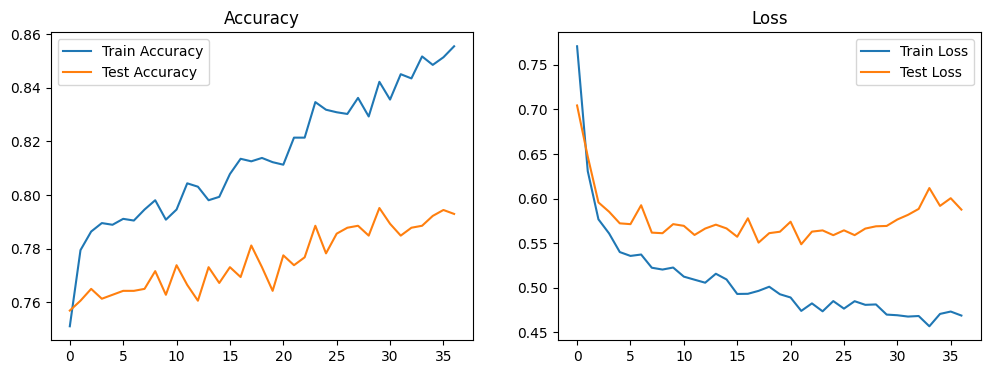

In [9]:
# CNN Model Definition
def build_cnn(input_shape):
    model = models.Sequential()
    
    # 1st Convolutional Layer with Dropout and L2 Regularization
    model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.3))

    # 2nd Convolutional Layer with Dropout and L2 Regularization
    model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.3))

    # 3rd Convolutional Layer with Dropout and L2 Regularization
    model.add(layers.Conv2D(128, kernel_size=(3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.4))

    # Flatten the output and add fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(layers.Dropout(0.5))

    # Output layer (binary classification)
    model.add(layers.Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Define the input shape for the CNN
input_shape = (128, 128, 1)

# Build the model
model = build_cnn(input_shape)

# Print the model summary
model.summary()

# Define early stopping with reduced patience to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train the model with reduced epochs and batch size for generalization
history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Plot accuracy and loss curves
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss')
plt.legend()

plt.show()


In [4]:
from tensorflow.keras.models import load_model


model = load_model(MFCC_model.keras)

NameError: name 'MFCC_model' is not defined